In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.8/883.8 kB 51.1 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 301MB/s]


In [5]:
%cd /content/drive/MyDrive/alpr.v1i.yolov11

/content/drive/MyDrive/alpr.v1i.yolov11


In [6]:
!ls

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [7]:
import os
import glob

# Define the root path of your dataset
dataset_path = '/content/drive/MyDrive/alpr.v1i.yolov11'

# Function to count files in a folder
def count_files(folder_path, file_extension):
    return len(glob.glob(os.path.join(folder_path, f'*.{file_extension}')))

# Count images and labels for each subset
train_image_count = count_files(os.path.join(dataset_path, 'train/images'), 'jpg')
train_label_count = count_files(os.path.join(dataset_path, 'train/labels'), 'txt')

test_image_count = count_files(os.path.join(dataset_path, 'test/images'), 'jpg')
test_label_count = count_files(os.path.join(dataset_path, 'test/labels'), 'txt')

valid_image_count = count_files(os.path.join(dataset_path, 'valid/images'), 'jpg')
valid_label_count = count_files(os.path.join(dataset_path, 'valid/labels'), 'txt')

# Display the counts
print(f"Train set: {train_image_count} images, {train_label_count} labels")
print(f"Test set: {test_image_count} images, {test_label_count} labels")
print(f"Valid set: {valid_image_count} images, {valid_label_count} labels")


Train set: 8073 images, 7993 labels
Test set: 200 images, 200 labels
Valid set: 1799 images, 1809 labels


In [8]:
from PIL import Image
def get_image_sizes(image_paths):
    sizes = []
    for image_path in image_paths:
        with Image.open(image_path) as img:
            sizes.append(img.size)  # img.size returns (width, height)
    return sizes


In [9]:
# # Get image paths
# train_image_paths = glob.glob(os.path.join(dataset_path, 'train/images/*.jpg'))
# test_image_paths = glob.glob(os.path.join(dataset_path, 'test/images/*.jpg'))
# valid_image_paths = glob.glob(os.path.join(dataset_path, 'valid/images/*.jpg'))

# # Get image sizes
# train_sizes = get_image_sizes(train_image_paths)
# test_sizes = get_image_sizes(test_image_paths)
# valid_sizes = get_image_sizes(valid_image_paths)

# # Find unique sizes for each dataset split
# print("Unique sizes in Train set:", set(train_sizes))
# print("Unique sizes in Test set:", set(test_sizes))
# print("Unique sizes in Valid set:", set(valid_sizes))


In [11]:
train_image_paths = glob.glob(os.path.join(dataset_path, 'train/images/*.jpg'))
test_image_paths = glob.glob(os.path.join(dataset_path, 'test/images/*.jpg'))
valid_image_paths = glob.glob(os.path.join(dataset_path, 'valid/images/*.jpg'))

In [12]:
import random

# Sample a subset of image paths (e.g., 100 images) from each split
def sample_image_paths(image_paths, sample_size=100):
    if len(image_paths) > sample_size:
        return random.sample(image_paths, sample_size)
    return image_paths

# Get a smaller subset for each split
train_sample = sample_image_paths(train_image_paths)
test_sample = sample_image_paths(test_image_paths)
valid_sample = sample_image_paths(valid_image_paths)

# Get image sizes for sampled subsets
train_sizes = get_image_sizes(train_sample)
test_sizes = get_image_sizes(test_sample)
valid_sizes = get_image_sizes(valid_sample)

# Find unique sizes for each dataset split
print("Unique sizes in Train set (sample):", set(train_sizes))
print("Unique sizes in Test set (sample):", set(test_sizes))
print("Unique sizes in Valid set (sample):", set(valid_sizes))


Unique sizes in Train set (sample): {(416, 416)}
Unique sizes in Test set (sample): {(416, 416)}
Unique sizes in Valid set (sample): {(416, 416)}


**Visualize Sample Images with Bounding Boxes**

In [13]:
import cv2
import matplotlib.pyplot as plt

def plot_image_with_bboxes(image_path, label_path):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image.shape

    # Load and draw bounding boxes
    with open(label_path, 'r') as file:
        for line in file:
            class_id, x_center, y_center, w, h = map(float, line.split())
            x_center, y_center, w, h = x_center * width, y_center * height, w * width, h * height

            # Calculate box coordinates
            x_min = int(x_center - w / 2)
            y_min = int(y_center - h / 2)
            x_max = int(x_center + w / 2)
            y_max = int(y_center + h / 2)

            # Draw rectangle and label
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
            cv2.putText(image, str(int(class_id)), (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Show image with bounding boxes
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Display a sample image from the training set
plot_image_with_bboxes(train_images[0], train_labels[0])


NameError: name 'train_images' is not defined

** Check for Missing Labels or Images in the Train Set**

In [14]:
import os

# Function to get image and label file names without extensions
def get_filenames(folder, extension):
    return set([os.path.splitext(file)[0] for file in os.listdir(folder) if file.endswith(extension)])

# Define paths for train images and labels
train_images_folder = os.path.join(dataset_path, 'train/images')
train_labels_folder = os.path.join(dataset_path, 'train/labels')

# Get image and label filenames
train_image_files = get_filenames(train_images_folder, '.jpg')
train_label_files = get_filenames(train_labels_folder, '.txt')

# Find missing labels or images
missing_labels = train_image_files - train_label_files
missing_images = train_label_files - train_image_files

print(f"Missing labels: {len(missing_labels)}")
print(f"Missing images: {len(missing_images)}")


Missing labels: 80
Missing images: 0


In [15]:
import shutil

# Path to store images without labels
backup_folder = os.path.join(dataset_path, 'train/images_without_labels')
os.makedirs(backup_folder, exist_ok=True)

# Move images without labels to the backup folder
for img_name in missing_labels:
    img_path = os.path.join(train_images_folder, img_name + '.jpg')
    shutil.move(img_path, backup_folder)

print(f"Moved {len(missing_labels)} images without labels to {backup_folder}")


Moved 80 images without labels to /content/drive/MyDrive/alpr.v1i.yolov11/train/images_without_labels


In [16]:
# Re-run the check to confirm that there are no missing labels
train_image_files = get_filenames(train_images_folder, '.jpg')
train_label_files = get_filenames(train_labels_folder, '.txt')

missing_labels = train_image_files - train_label_files
missing_images = train_label_files - train_image_files

print(f"Missing labels after cleanup: {len(missing_labels)}")
print(f"Missing images after cleanup: {len(missing_images)}")


Missing labels after cleanup: 0
Missing images after cleanup: 0


In [17]:
import os

# Function to get image and label file names without extensions
def get_filenames(folder, extension):
    return set([os.path.splitext(file)[0] for file in os.listdir(folder) if file.endswith(extension)])

# Define paths for train images and labels
train_images_folder = os.path.join(dataset_path, 'valid/images')
train_labels_folder = os.path.join(dataset_path, 'valid/labels')

# Get image and label filenames
train_image_files = get_filenames(train_images_folder, '.jpg')
train_label_files = get_filenames(train_labels_folder, '.txt')

# Find missing labels or images
missing_labels = train_image_files - train_label_files
missing_images = train_label_files - train_image_files

print(f"Missing labels: {len(missing_labels)}")
print(f"Missing images: {len(missing_images)}")

Missing labels: 0
Missing images: 10


In [18]:
# Path to store labels without images
backup_labels_folder = os.path.join(dataset_path, 'train/labels_without_images')
os.makedirs(backup_labels_folder, exist_ok=True)

# Move labels without images to the backup folder
for label_name in missing_images:
    label_path = os.path.join(train_labels_folder, label_name + '.txt')
    shutil.move(label_path, backup_labels_folder)

print(f"Moved {len(missing_images)} labels without images to {backup_labels_folder}")


Moved 10 labels without images to /content/drive/MyDrive/alpr.v1i.yolov11/train/labels_without_images


In [19]:
# Re-run the check to confirm no labels are missing images
train_image_files = get_filenames(train_images_folder, '.jpg')
train_label_files = get_filenames(train_labels_folder, '.txt')

missing_labels = train_image_files - train_label_files
missing_images = train_label_files - train_image_files

print(f"Missing labels after cleanup: {len(missing_labels)}")
print(f"Missing images after cleanup: {len(missing_images)}")


Missing labels after cleanup: 0
Missing images after cleanup: 0


In [20]:
import os

# Function to get image and label file names without extensions
def get_filenames(folder, extension):
    return set([os.path.splitext(file)[0] for file in os.listdir(folder) if file.endswith(extension)])

# Define paths for train images and labels
train_images_folder = os.path.join(dataset_path, 'test/images')
train_labels_folder = os.path.join(dataset_path, 'test/labels')

# Get image and label filenames
train_image_files = get_filenames(train_images_folder, '.jpg')
train_label_files = get_filenames(train_labels_folder, '.txt')

# Find missing labels or images
missing_labels = train_image_files - train_label_files
missing_images = train_label_files - train_image_files

print(f"Missing labels: {len(missing_labels)}")
print(f"Missing images: {len(missing_images)}")

Missing labels: 0
Missing images: 0


**Training**

In [21]:
!yolo task=detect mode=train model=yolo11n.pt data=/content/drive/MyDrive/alpr.v1i.yolov11/data.yaml epochs=80 imgsz=640 plots=True

100% 5.35M/5.35M [00:00<00:00, 271MB/s]
Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/alpr.v1i.yolov11/data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sa

In [26]:
from IPython.display import Image,display

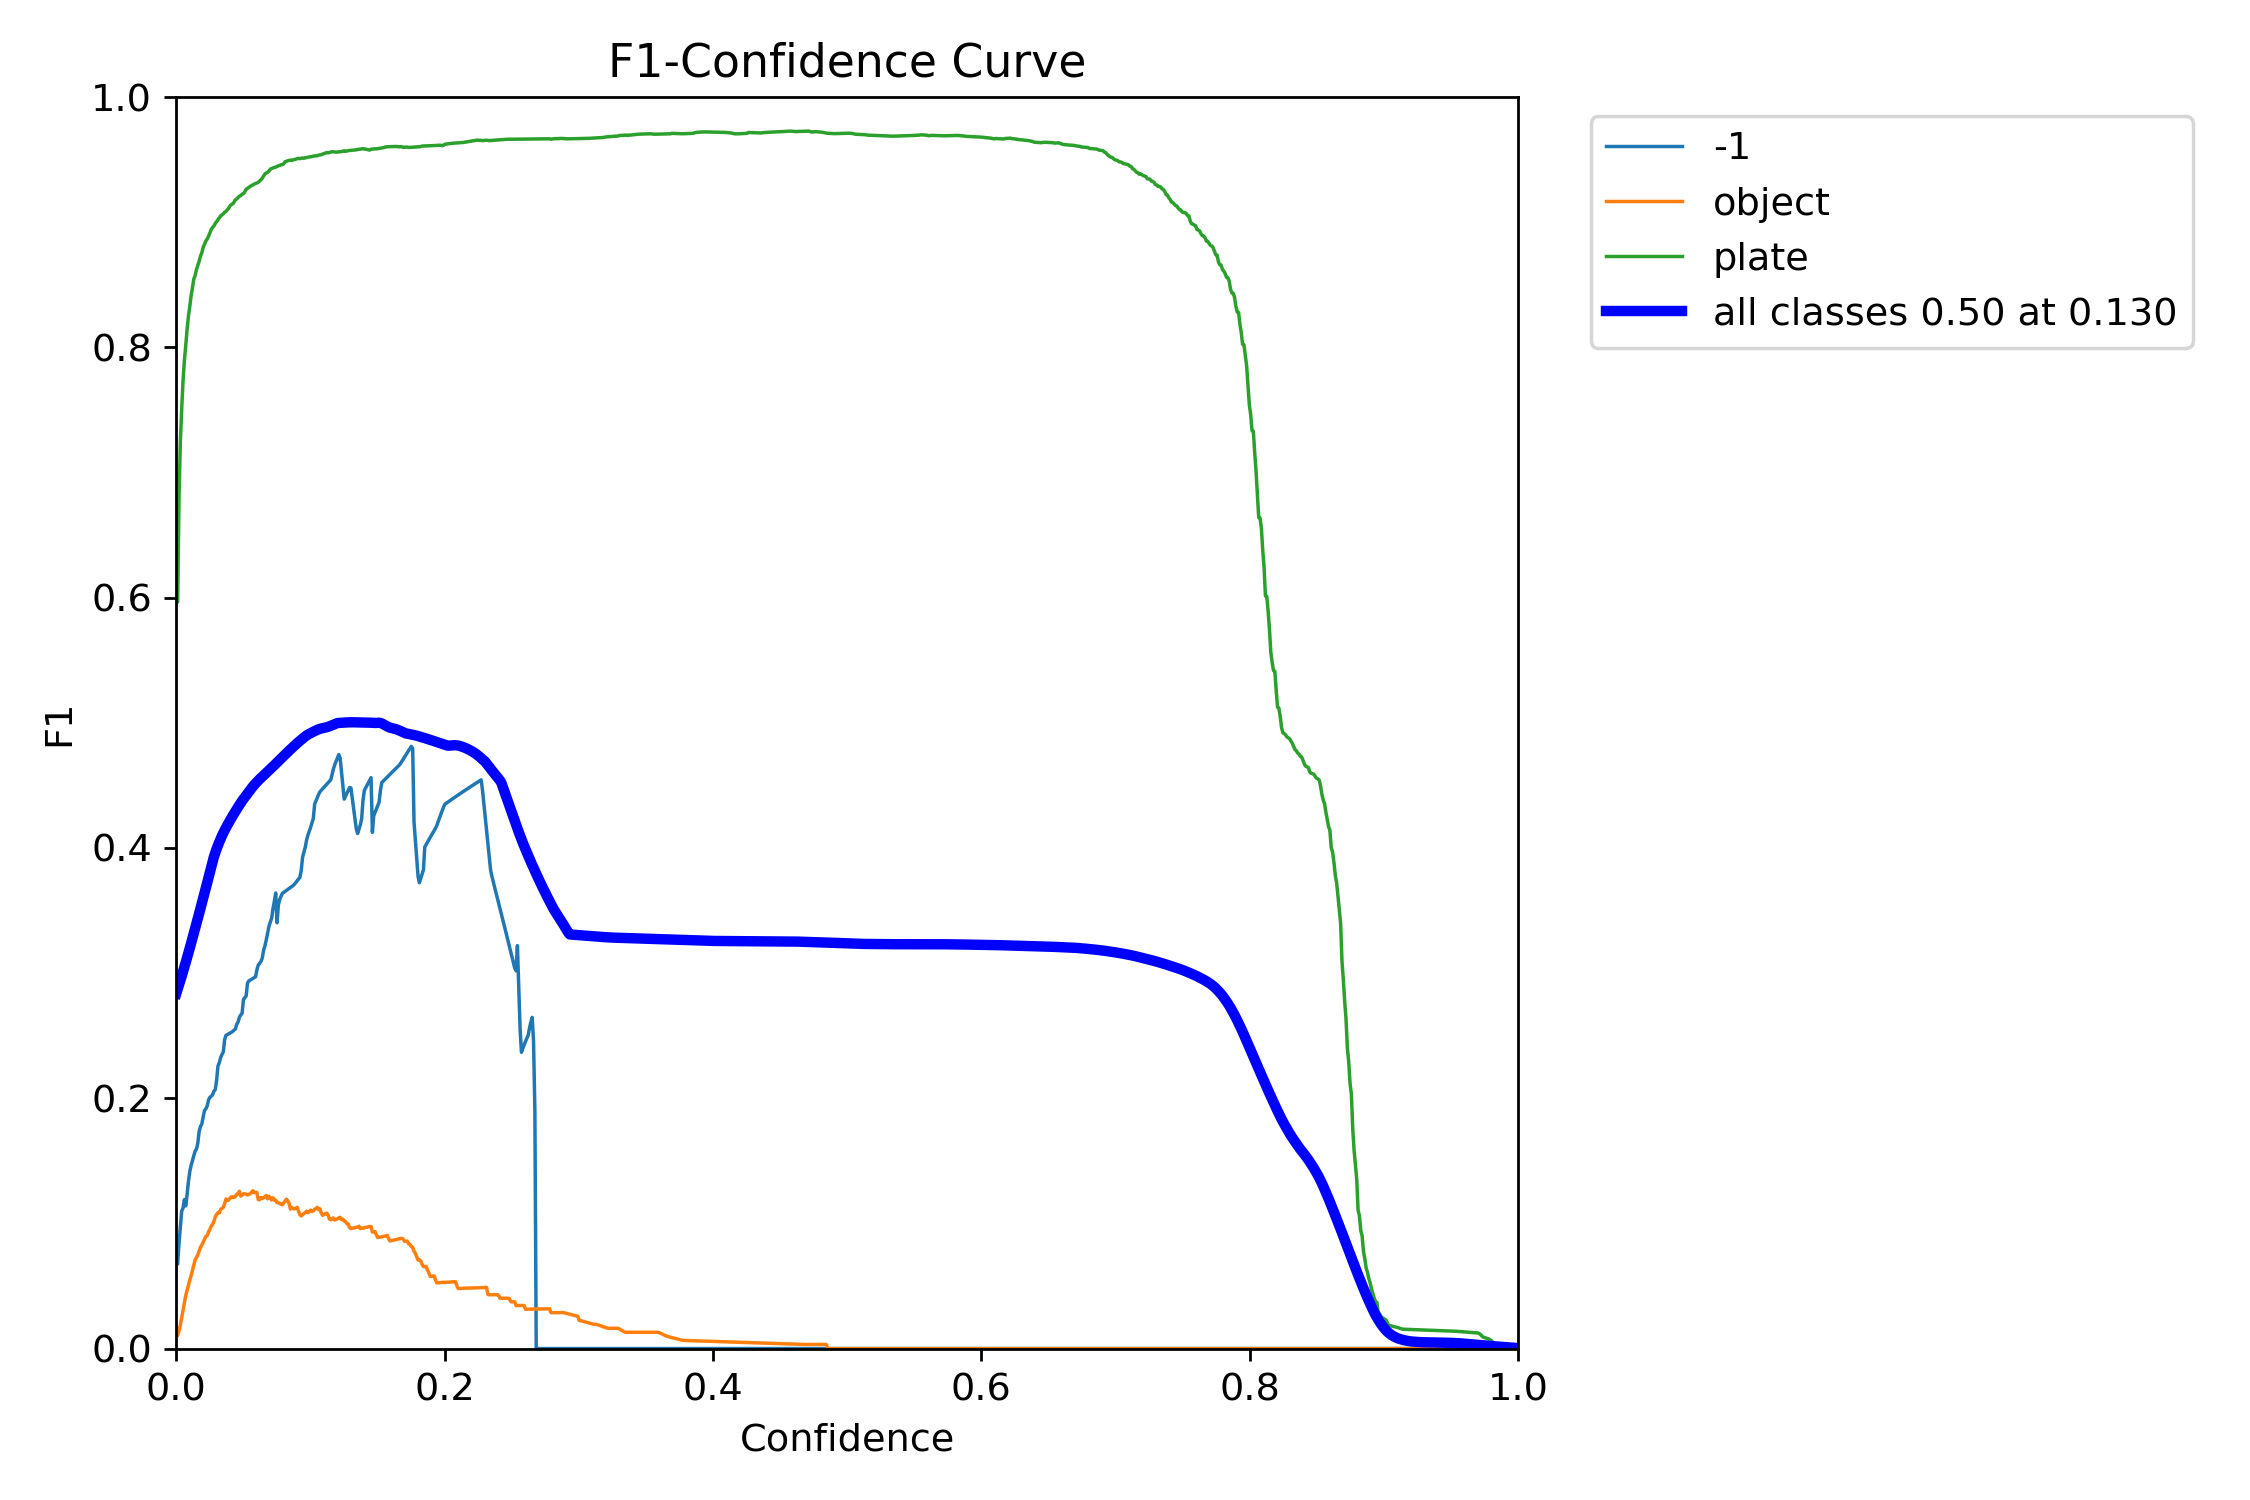

In [27]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/F1_curve.png', width=600))

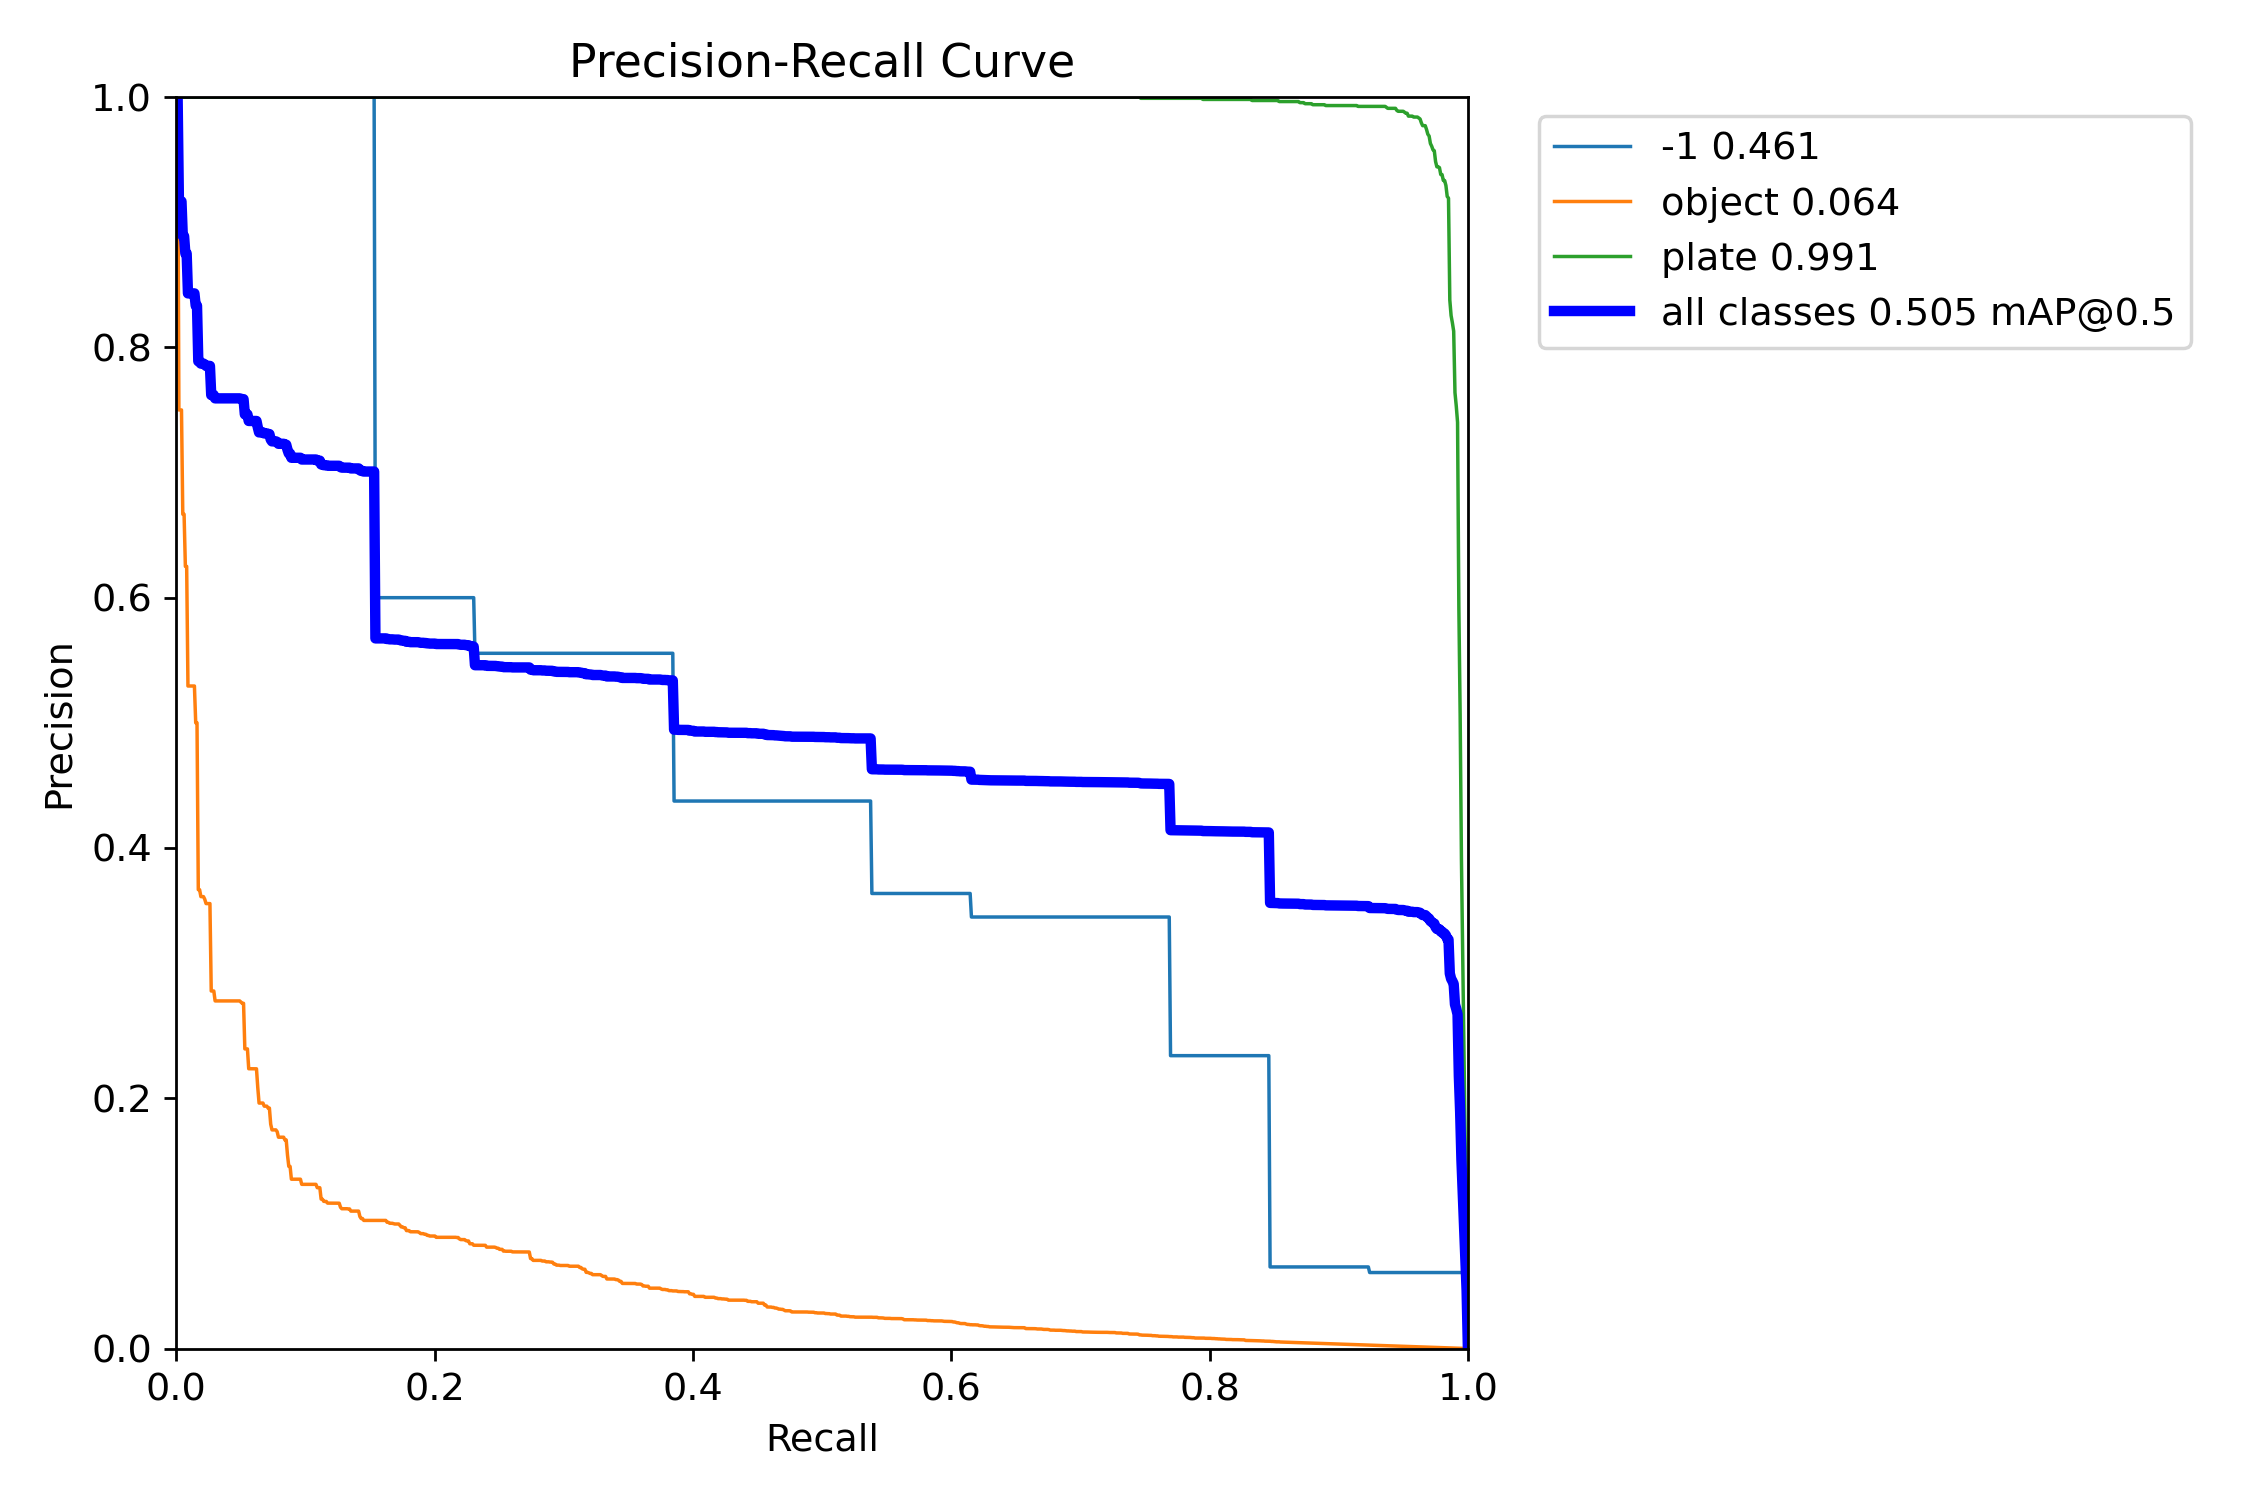

In [28]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/PR_curve.png', width=600))

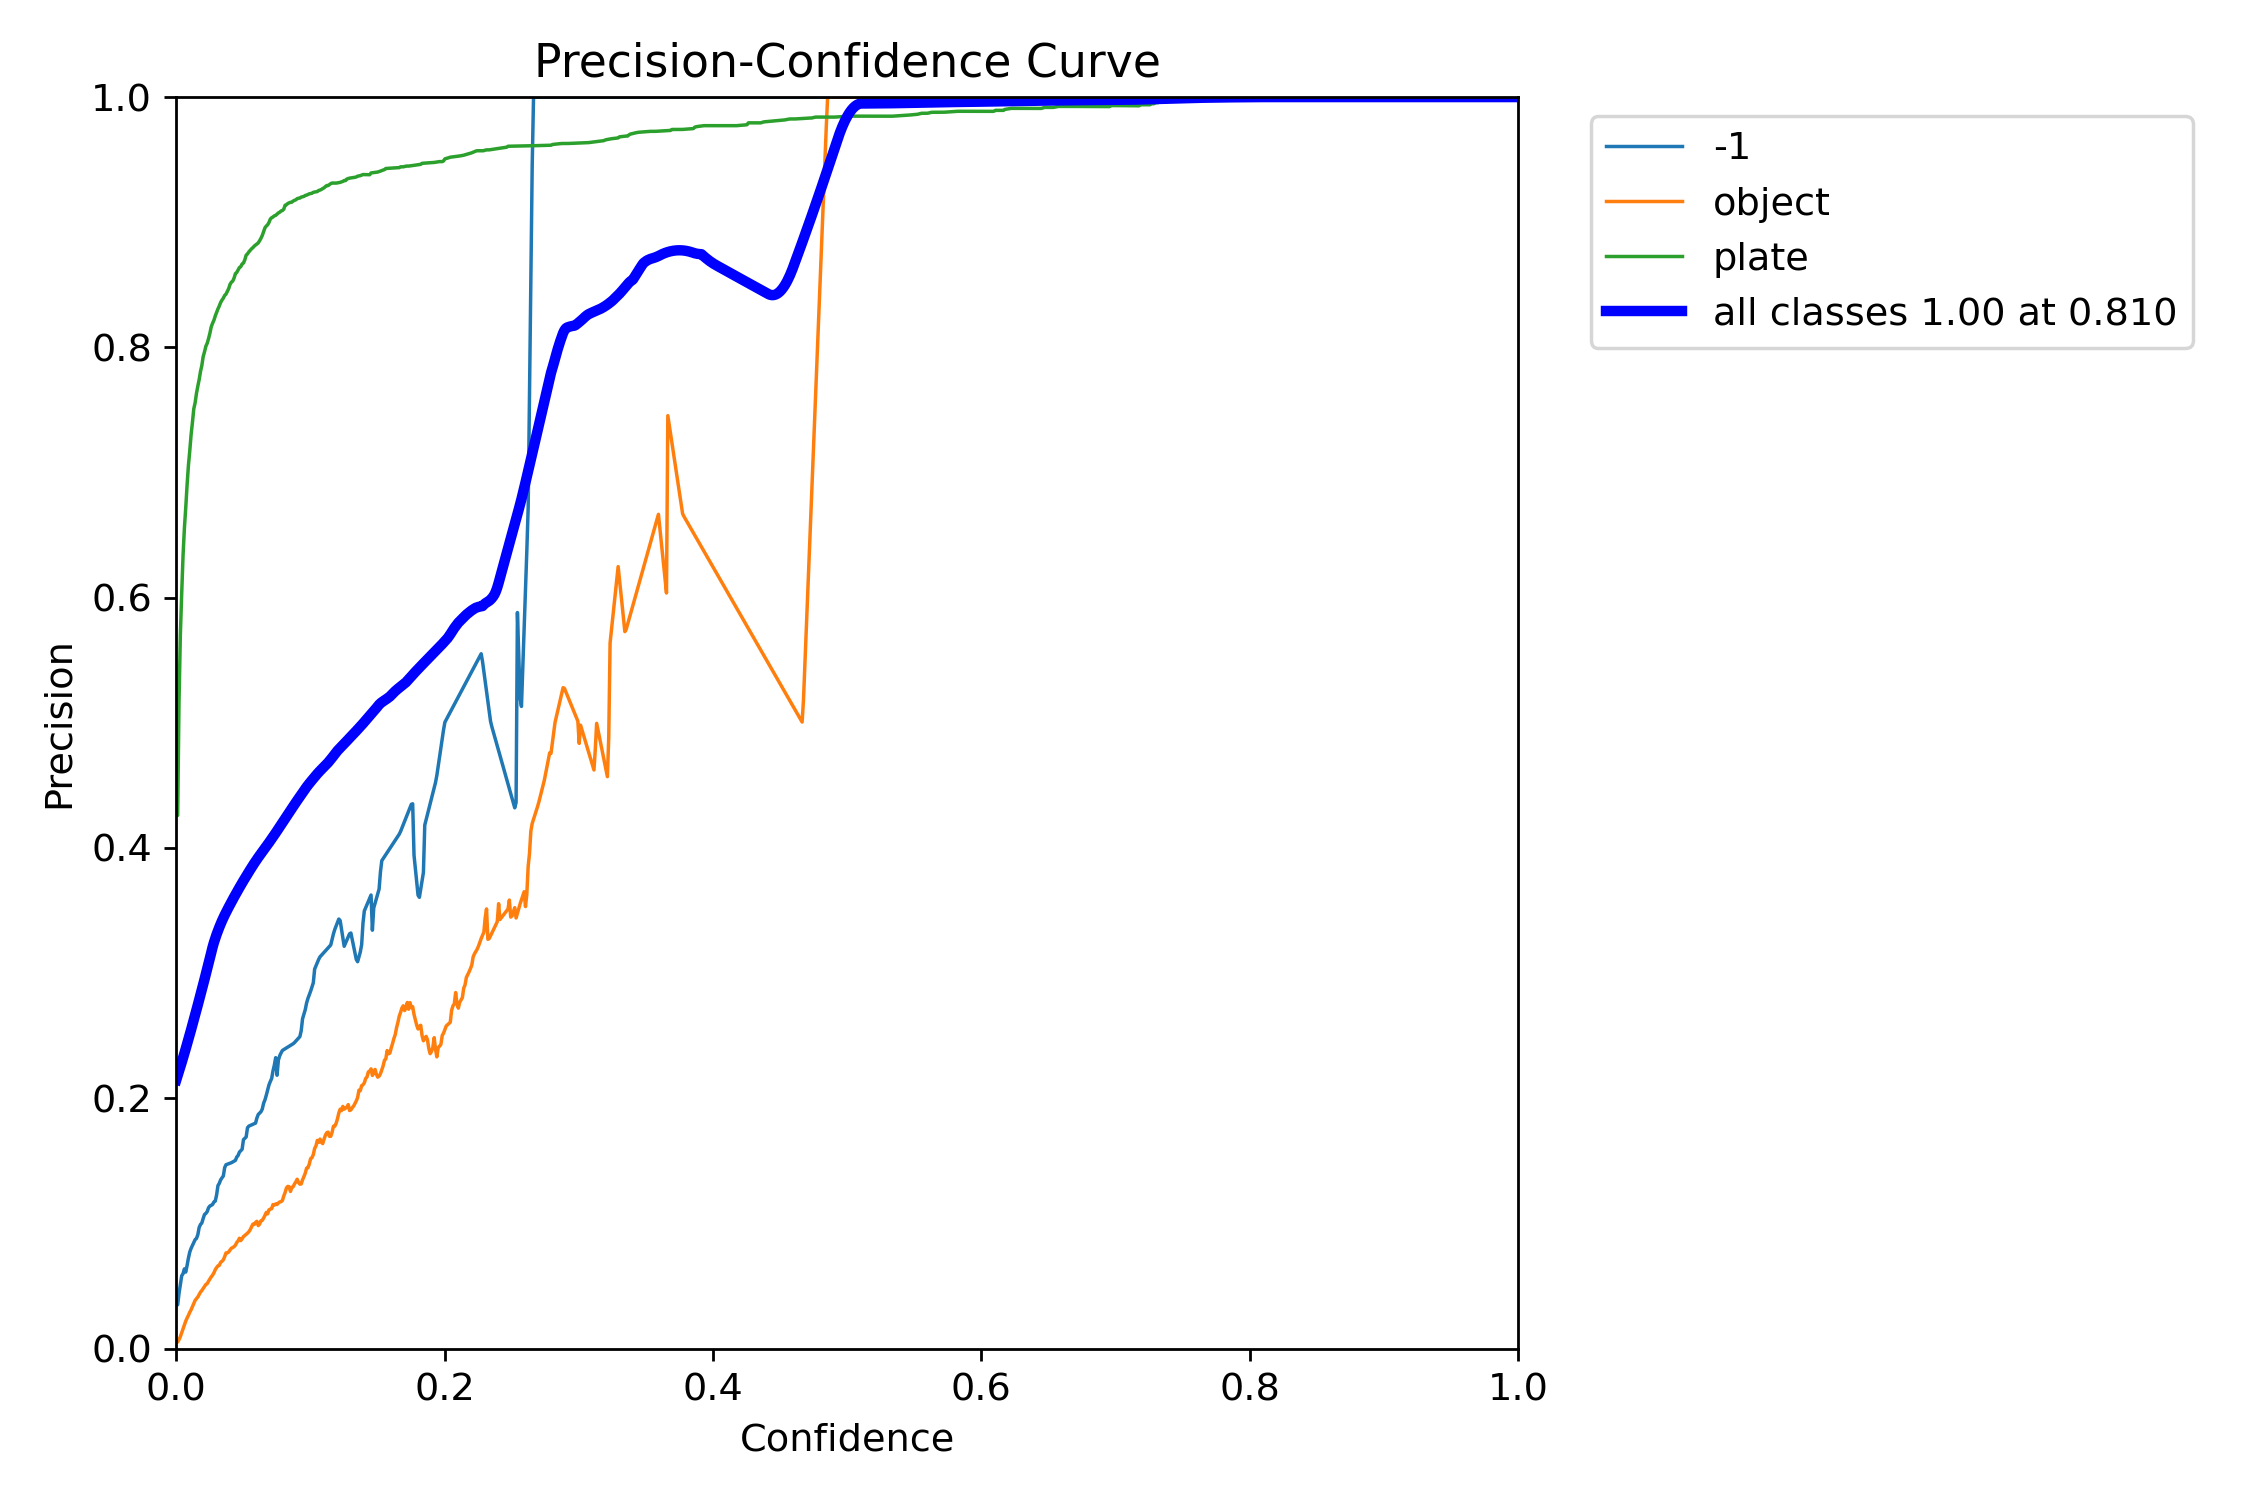

In [29]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/P_curve.png', width=600))

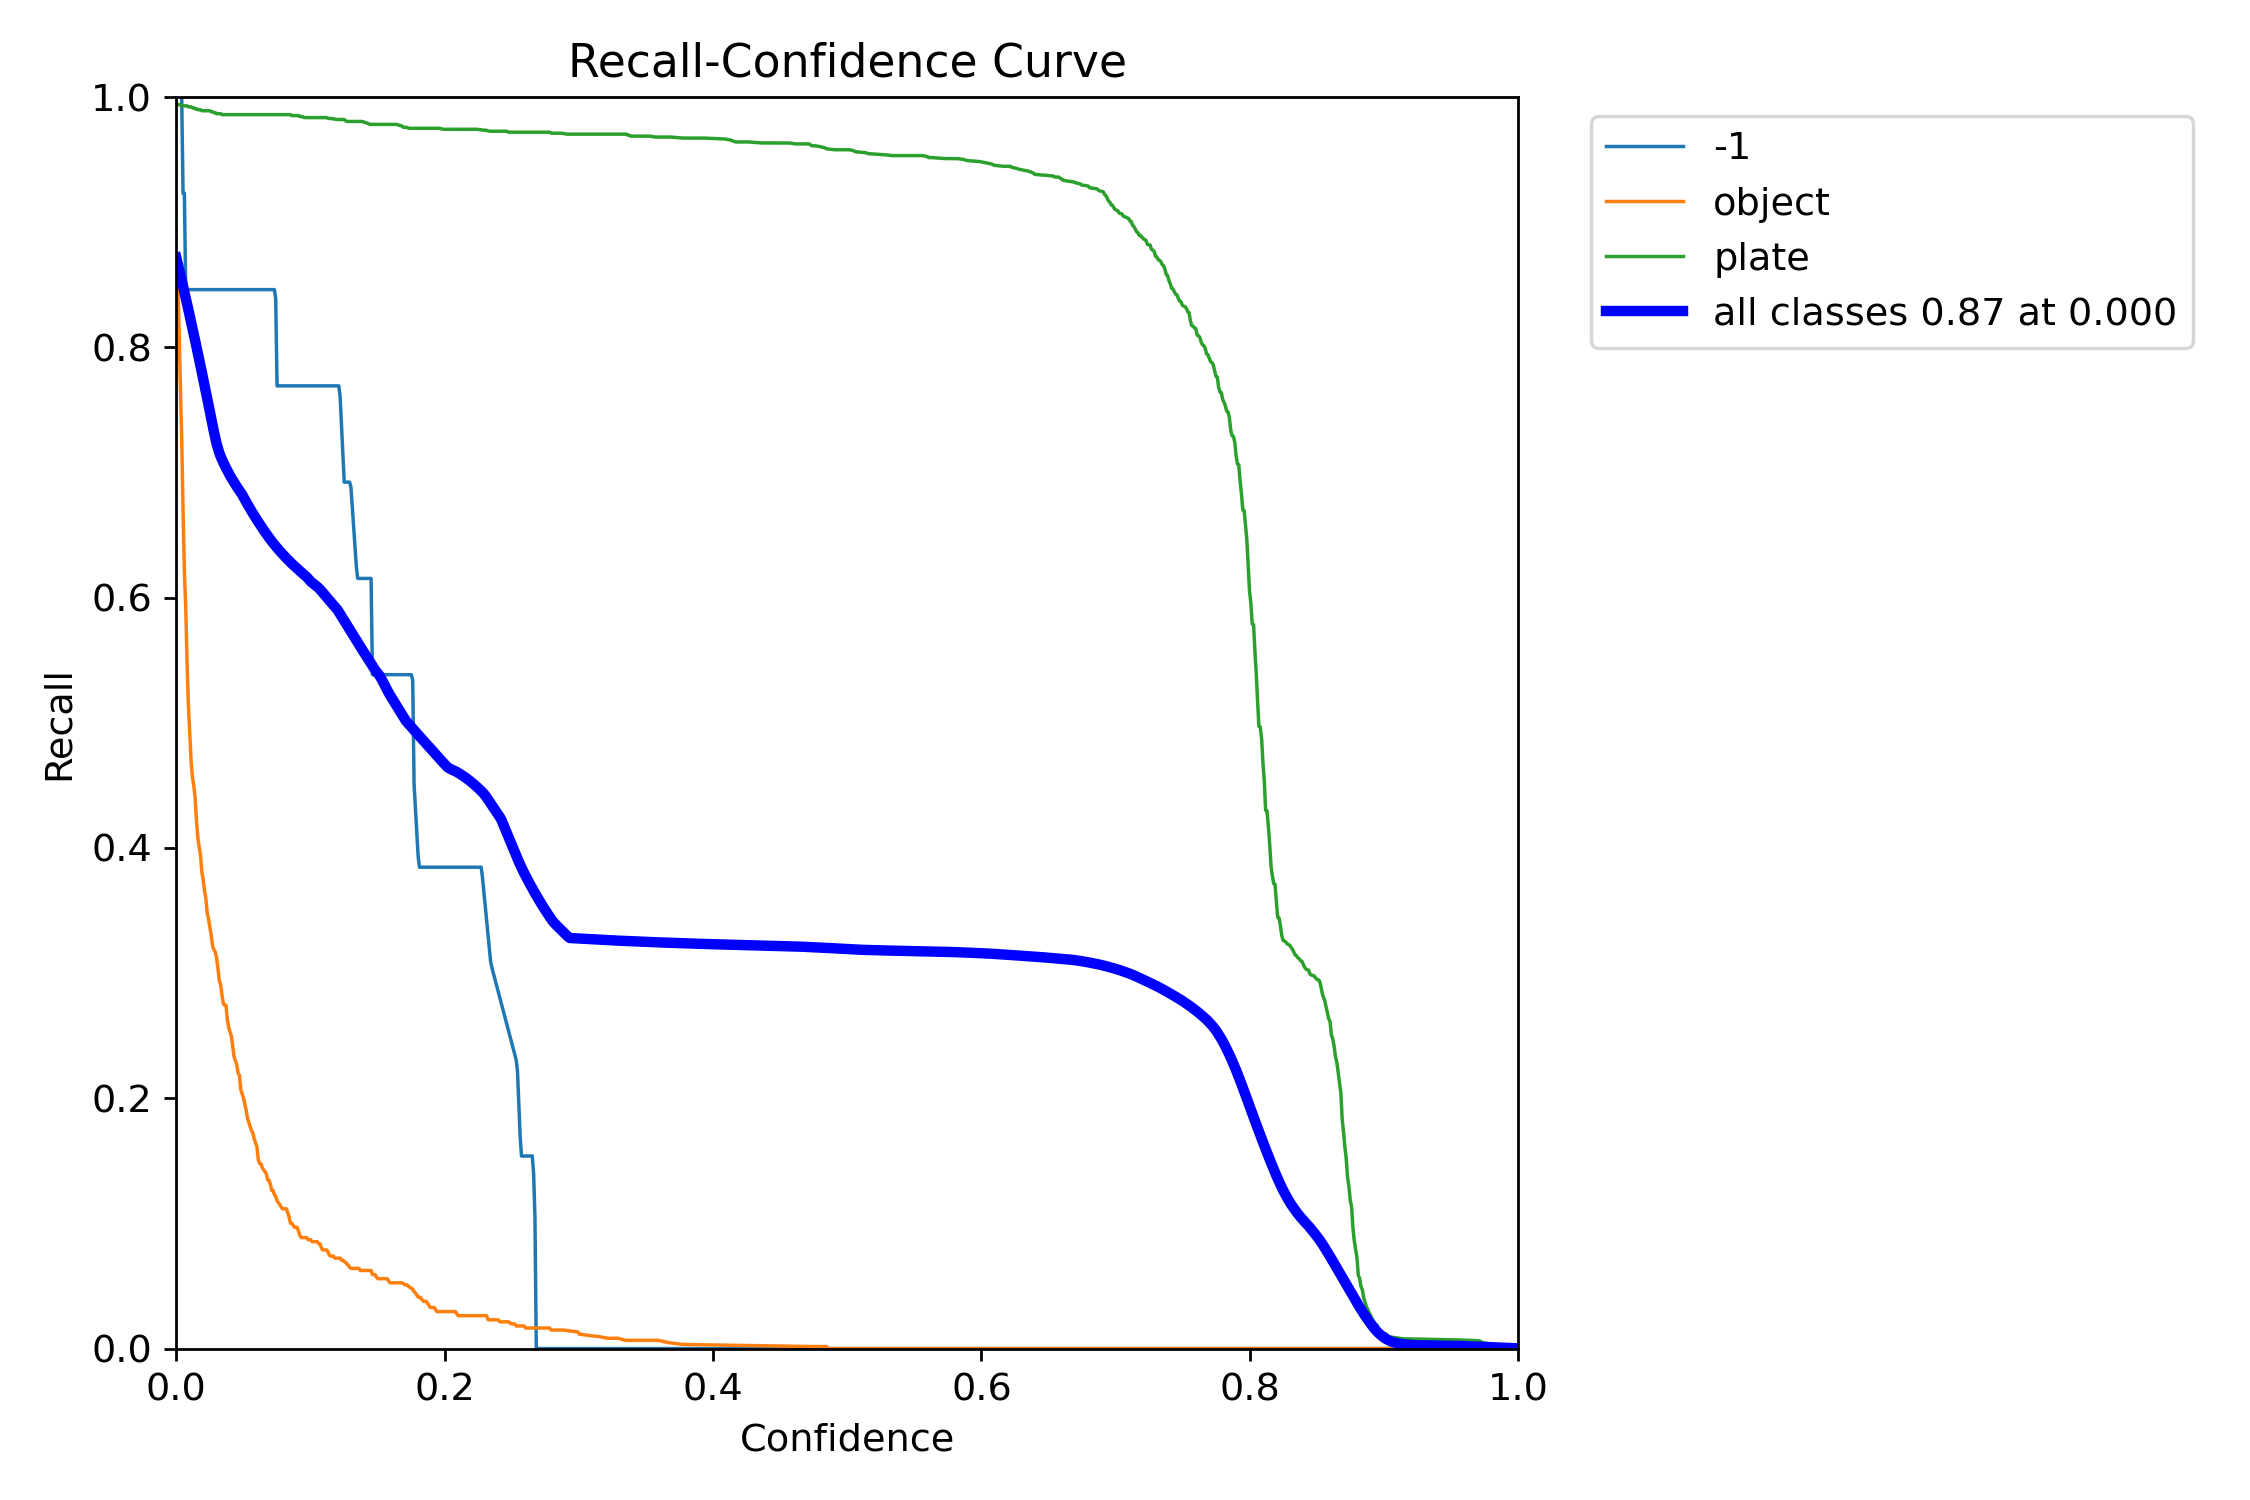

In [30]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/R_curve.png', width=600))

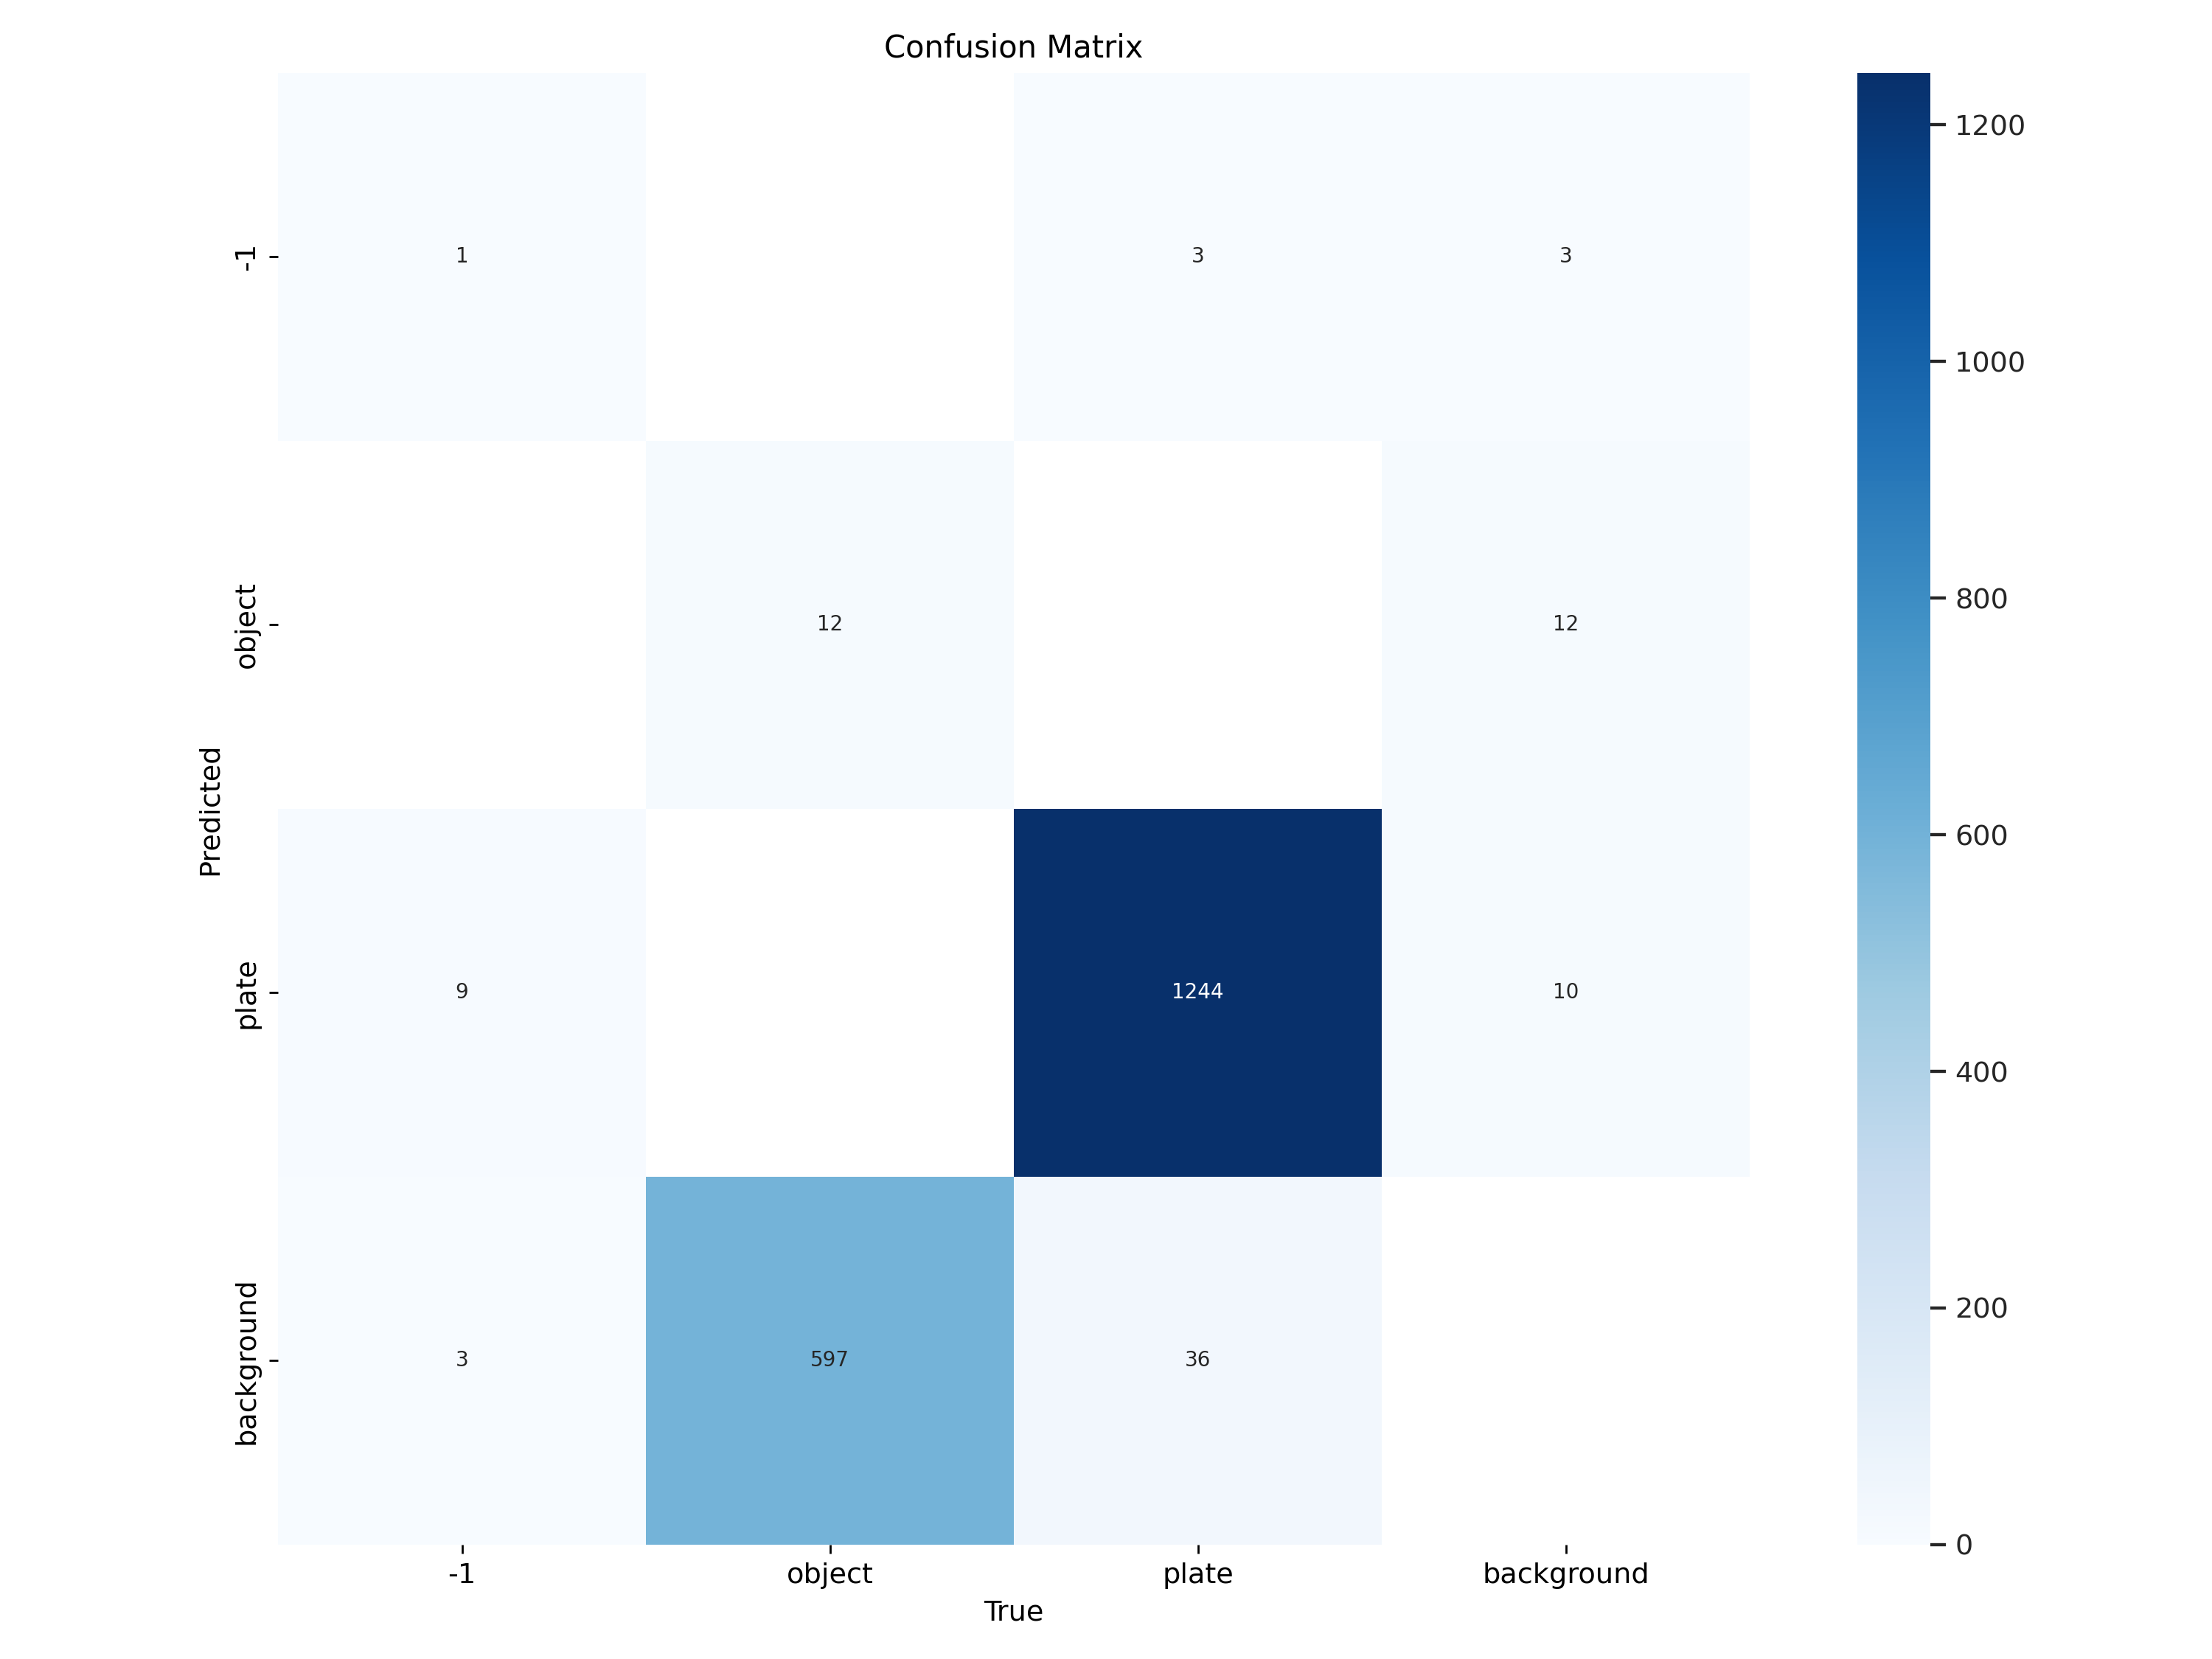

In [31]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/confusion_matrix.png', width=600))

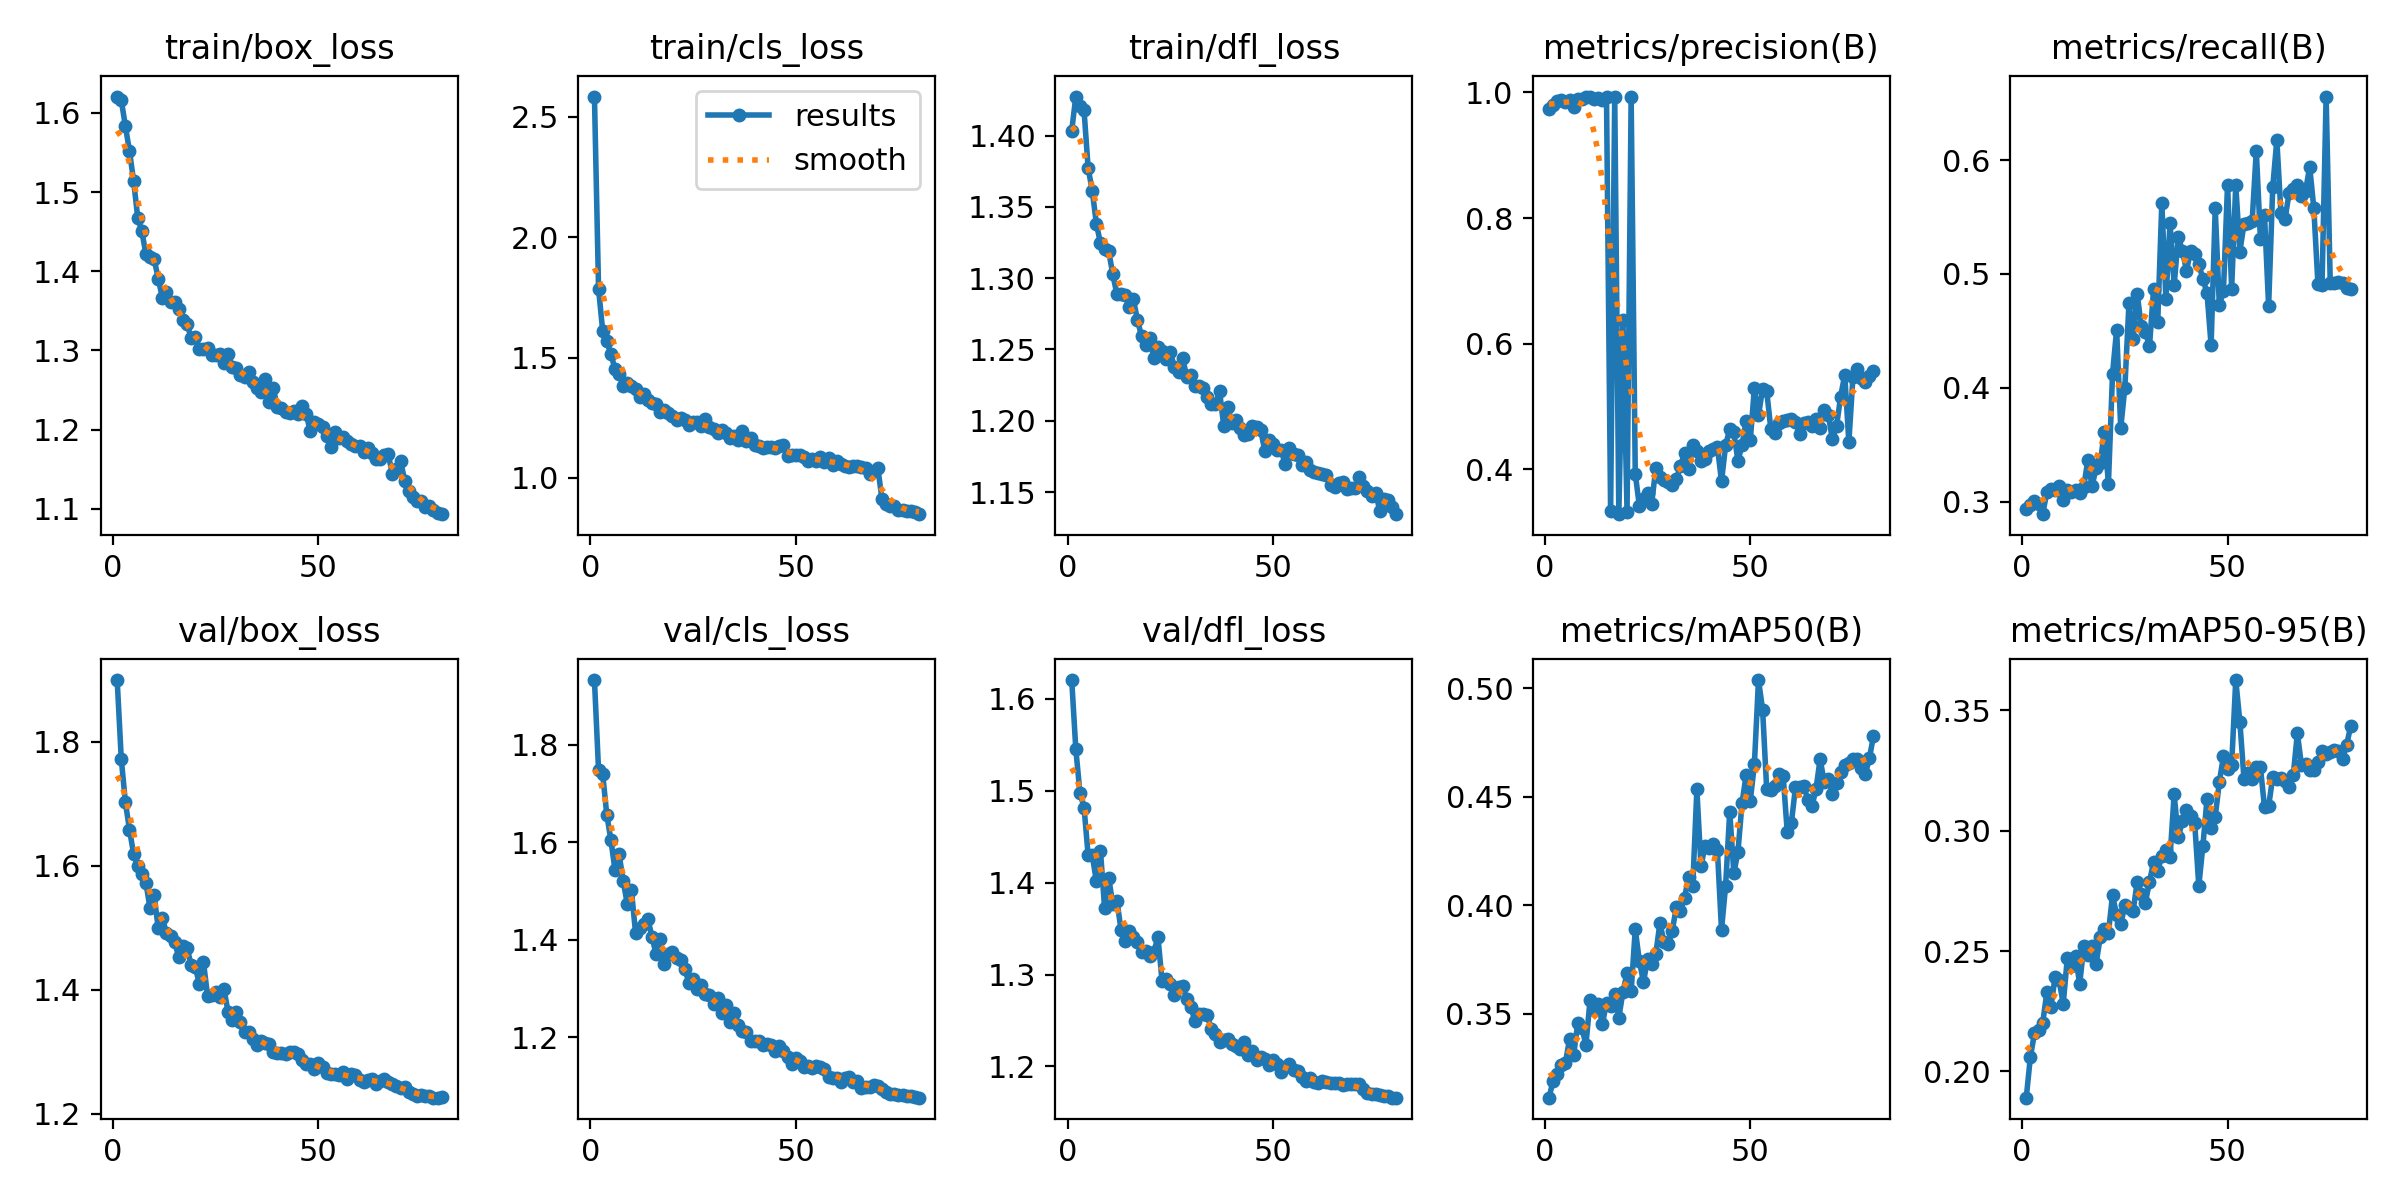

In [32]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/results.png', width=600))

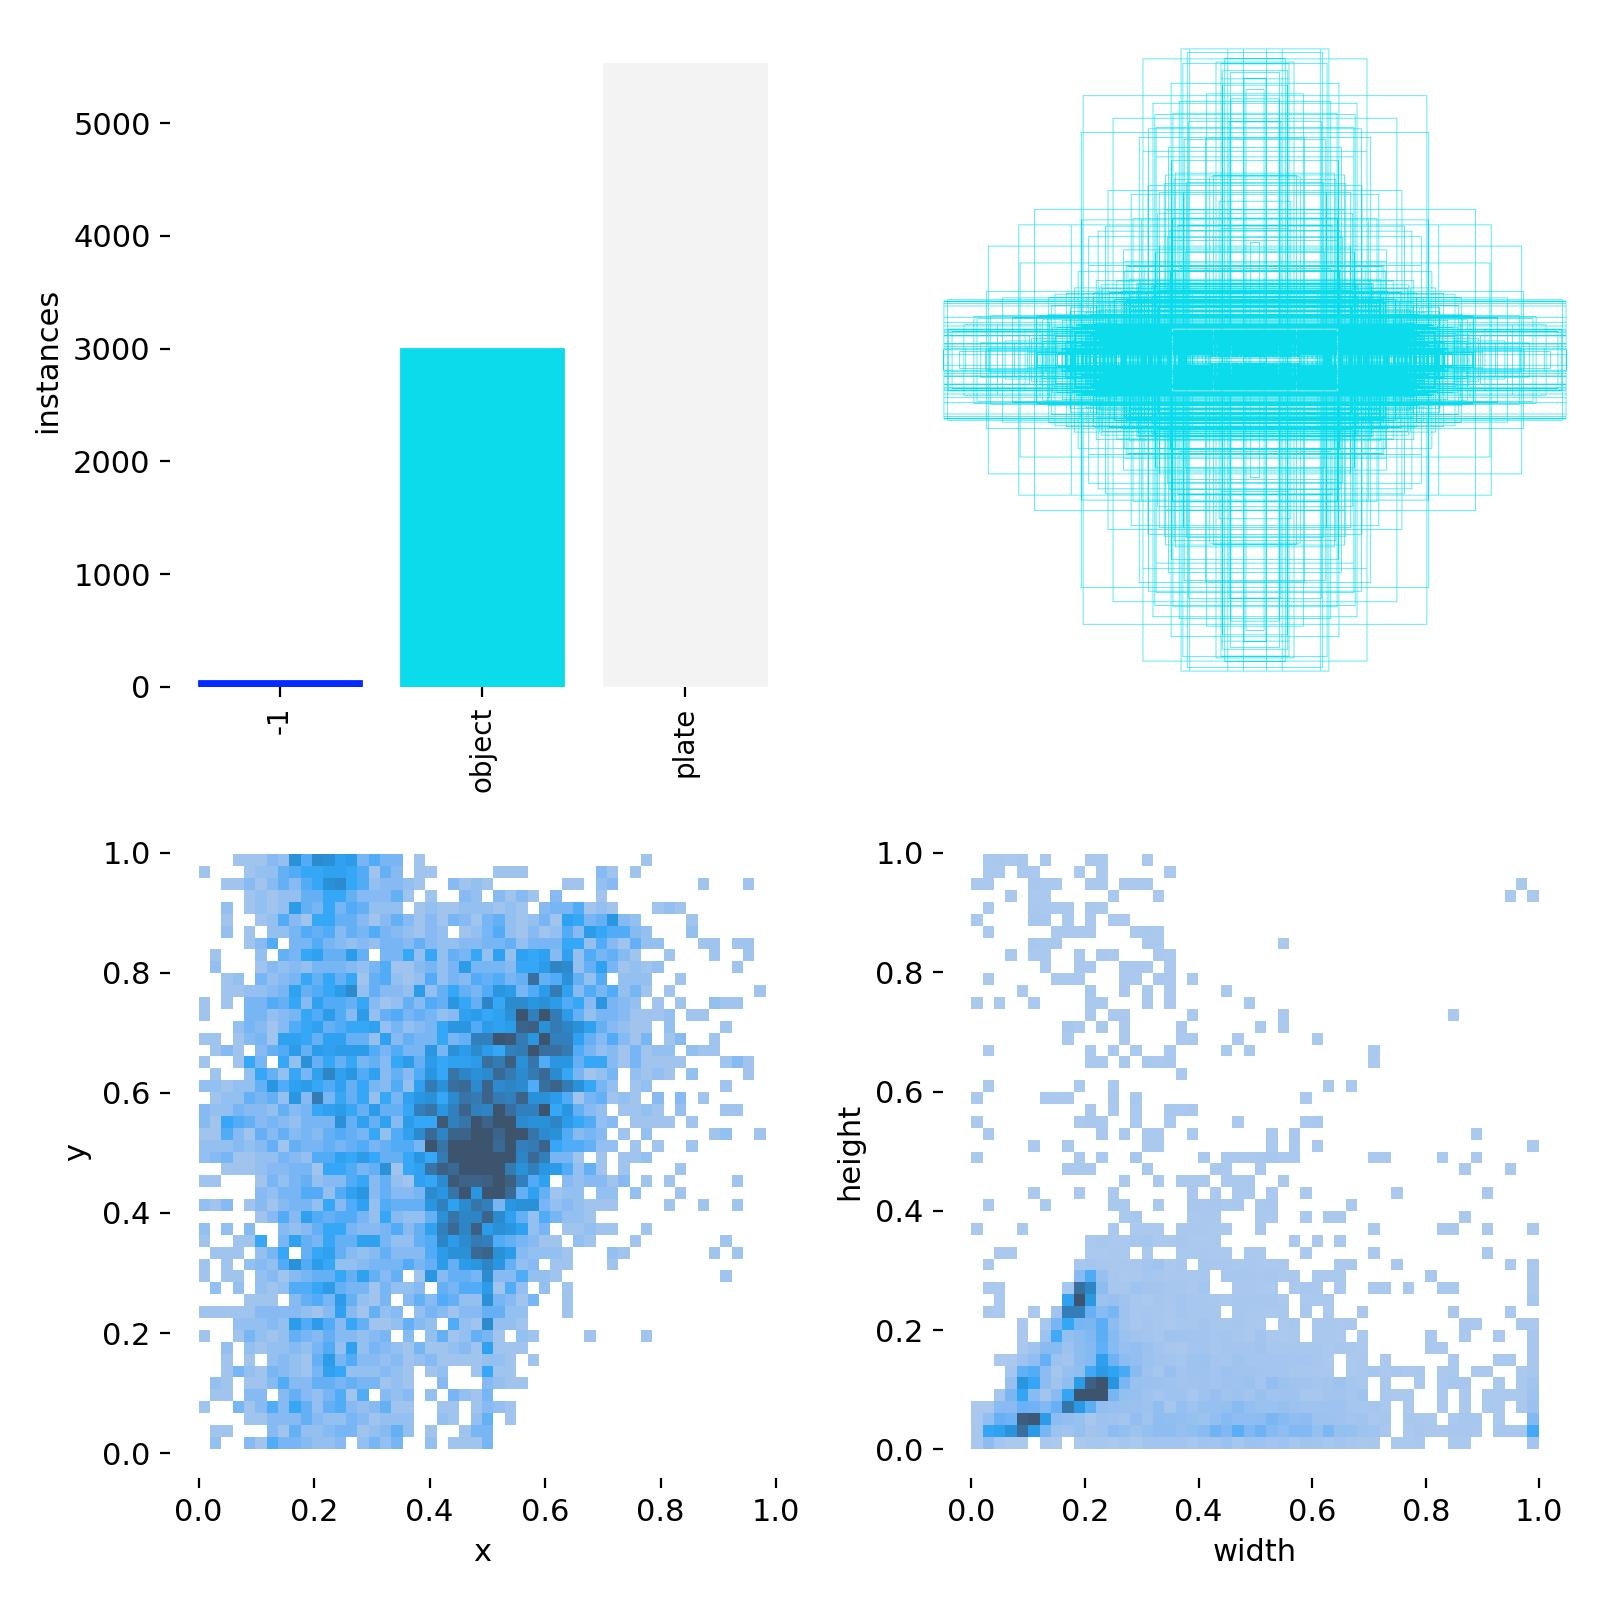

In [33]:
display(Image(filename='/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/labels.jpg', width=600))

In [34]:
!yolo task=detect mode=val model=/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/weights/best.pt data=/content/drive/MyDrive/alpr.v1i.yolov11/data.yaml

Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/drive/MyDrive/alpr.v1i.yolov11/valid/labels.cache... 1799 images, 67 backgrounds, 0 corrupt: 100% 1799/1799 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 113/113 [00:22<00:00,  5.00it/s]
                   all       1799       1905      0.486      0.579      0.504      0.363
                    -1         11         13      0.333      0.691      0.457      0.319
                object        466        609       0.19     0.0645     0.0634     0.0328
                 plate       1255       1283      0.935      0.981      0.991      0.737
Speed: 0.3ms preprocess, 0.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [39]:
infer = YOLO("/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/weights/best.pt")

In [44]:
infer.predict("/content/drive/MyDrive/alpr.v1i.yolov11/test/images/0d8fb19757f8dfe7_jpg.rf.4736a2bc638c6d3a7fc09a0979662fe9.jpg", save = True, save_txt = True)


image 1/1 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/0d8fb19757f8dfe7_jpg.rf.4736a2bc638c6d3a7fc09a0979662fe9.jpg: 640x640 1 object, 12.3ms
Speed: 4.4ms preprocess, 12.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict
1 label saved to runs/detect/predict/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '-1', 1: 'object', 2: 'plate'}
 obb: None
 orig_img: array([[[  1,   0, 113],
         [  1,   0, 113],
         [  1,   0, 113],
         ...,
         [  2,   0,  76],
         [  3,   1,  77],
         [  4,   2,  78]],
 
        [[  1,   0, 113],
         [  1,   0, 113],
         [  1,   0, 113],
         ...,
         [  4,   2,  78],
         [  5,   3,  79],
         [  5,   3,  79]],
 
        [[  1,   0, 112],
         [  1,   0, 112],
         [  1,   0, 112],
         ...,
         [  5,   3,  79],
         [  6,   4,  80],
         [  6,   4,  80]],
 
        ...,
 
        [[  9,  10, 101],
         [  8,   9, 100],
         [  7,   8,  99],
         ...,
         [  0,   0,  64],
         [  0,   0,  64],
         [  0,   0,  64]],
 
        [[  6,   7,  98],
         [  6,   7,  98],
         [  5,   6,  97],
         ..

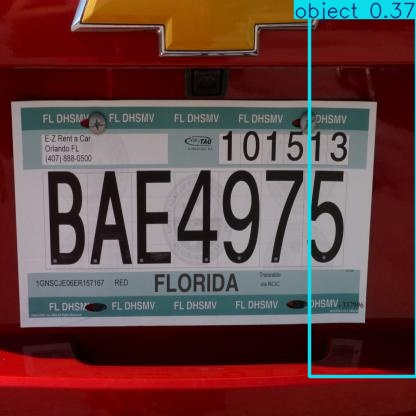

In [47]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/predict/0d8fb19757f8dfe7_jpg.rf.4736a2bc638c6d3a7fc09a0979662fe9.jpg'):
      display(Image(filename=image_path, width=600))
      print("\n")

In [48]:
!yolo task=detect mode=predict model=/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/train/weights/best.pt conf=0.25 source=/content/drive/MyDrive/alpr.v1i.yolov11/test/images save=True

Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/200 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/002d099996f3f443_jpg.rf.9fc9bda5138a7e331be3768529a95e99.jpg: 640x640 (no detections), 11.3ms
image 2/200 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/005706e3eb3d276f_jpg.rf.4d4672eea953882dd5f6c0bbc68e04c5.jpg: 640x640 (no detections), 9.7ms
image 3/200 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/009824ffd4586a33_jpg.rf.2b79d84833be880c9276d47891026b56.jpg: 640x640 (no detections), 10.8ms
image 4/200 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/011313e10dcd6d12_jpg.rf.15fc9a8ac473149b79e1f148faf51b8b.jpg: 640x640 (no detections), 10.2ms
image 5/200 /content/drive/MyDrive/alpr.v1i.yolov11/test/images/018e165c556b2eb6_jpg.rf.721e8a8c4f9cbe3d41d99532bd6a4fc1.jpg: 640x640 (no detections), 9.5ms
image 6/200 /content/drive/MyDriv

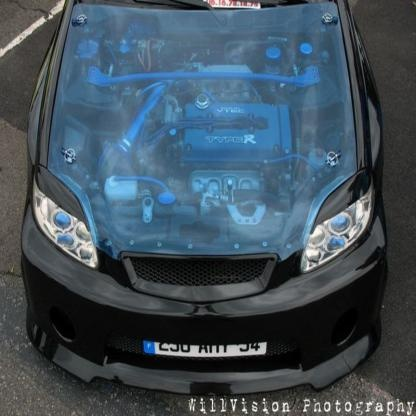

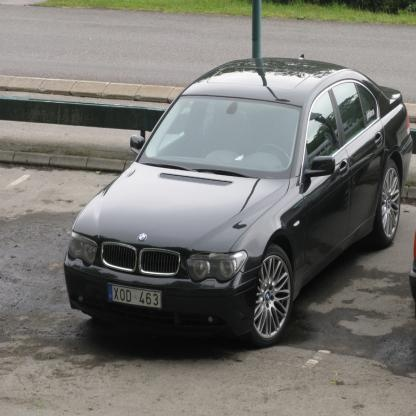

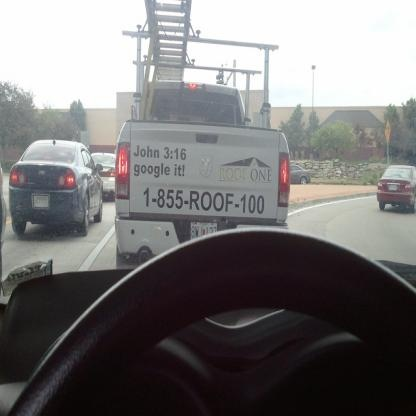

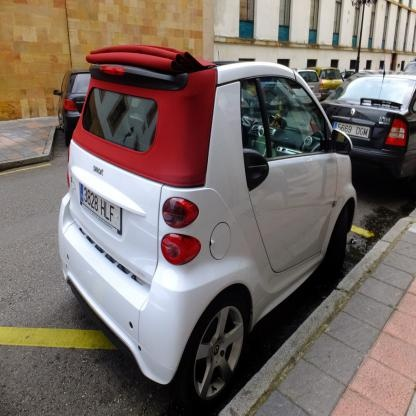

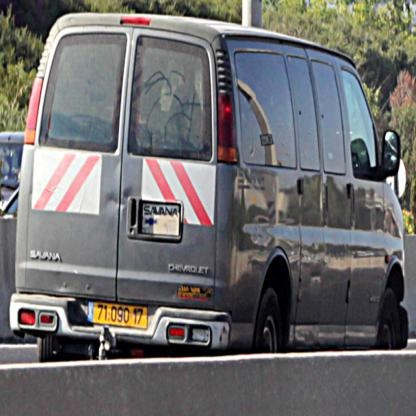

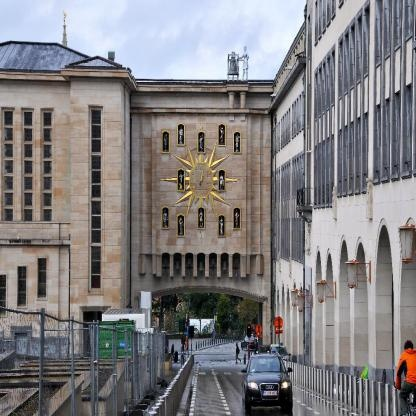

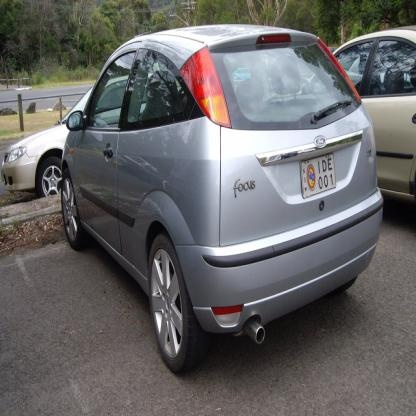

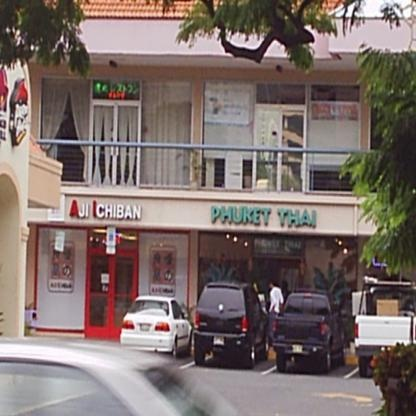

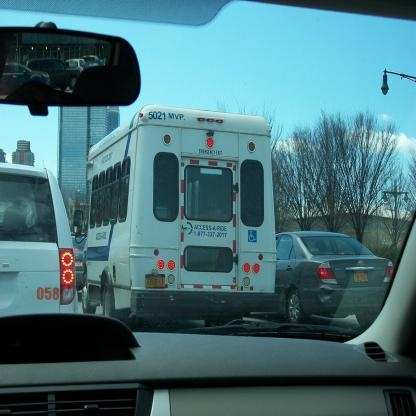

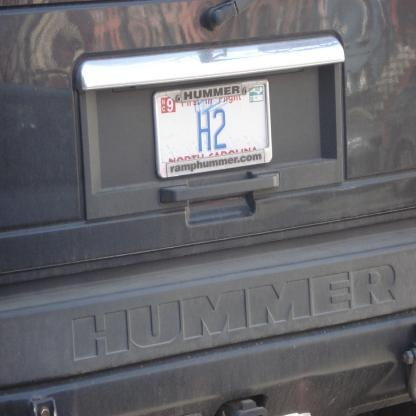

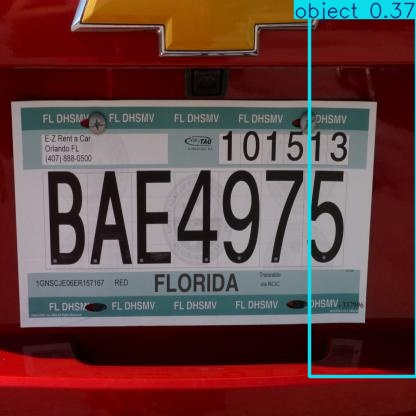

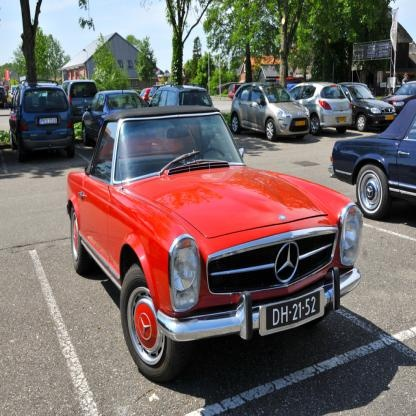

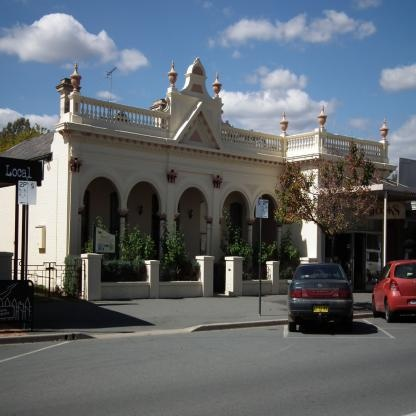

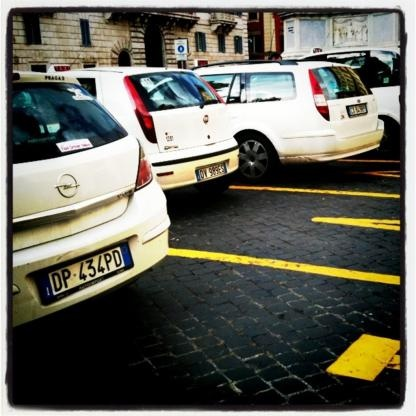

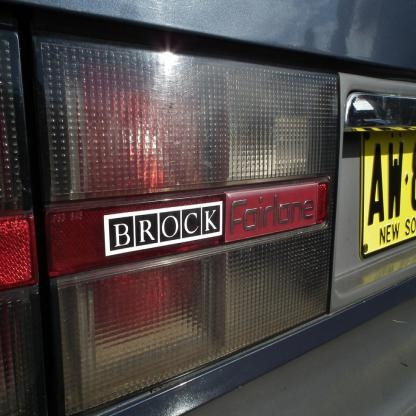

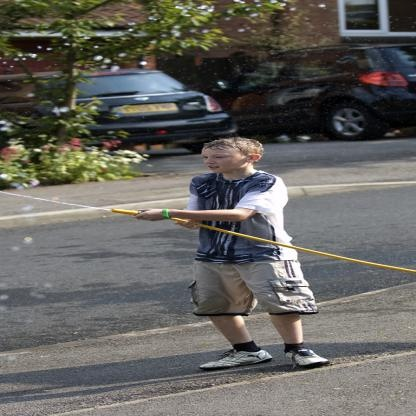

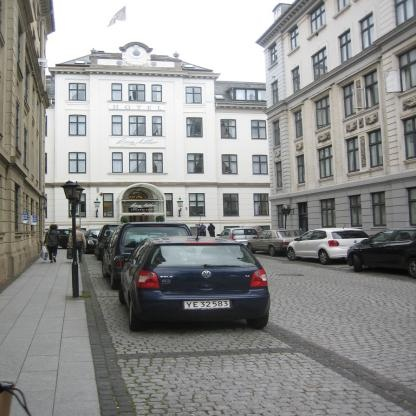

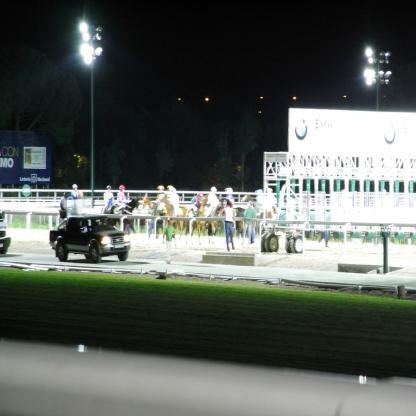

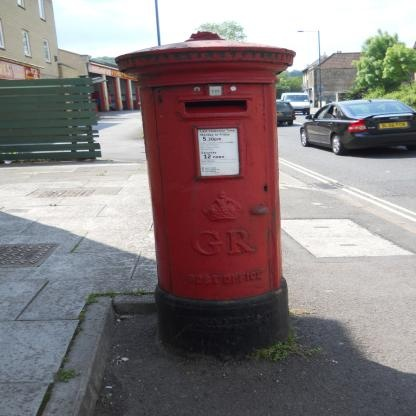

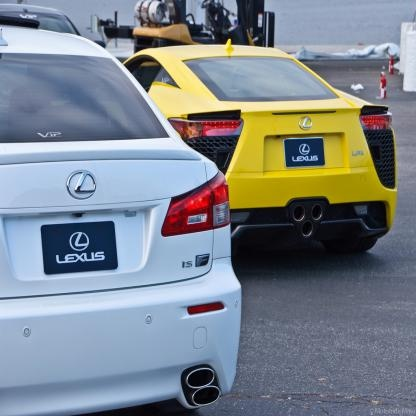

In [58]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/drive/MyDrive/alpr.v1i.yolov11/runs/detect/predict2'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:20]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
#for vedio
!yolo detect predict model = "/content/drive/MyDrive/final_colors_detection_yolov8/runs/detect/train4/weights/best.pt" source = "/content/drive/MyDrive/20230626_133612.mp4" save = True, save_txt = True